In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

In [2]:
import fsspec
from zipfile import ZipFile
from io import BytesIO

def load_specific_csv_from_zip(url, filename):
    """Load one specific CSV from multi-file ZIP"""
    with fsspec.open(url, 'rb') as f:
        with ZipFile(BytesIO(f.read())) as z:
            return pd.read_csv(z.open(filename))

PALETTE = {
    'Wheels Up':     '#E65100',
    'NetJets':       '#1565C0',
    'Flexjet':       '#6A1B9A',
    'Vista Group':   '#00695C',
    'flyExclusive':  '#AD1457',
    'Exec Jet Mgmt': '#558B2F',
    'Solairus':      '#4E342E',
    'Jet Linx':      '#37474F',
    'Other':         '#424242',
}

YEAR_COLORS = {'2023': '#90CAF9', '2024': '#EF9A9A', '2025': '#A5D6A7', '2026': '#E65100'}

Q1_FILES = {
    '2023': load_specific_csv_from_zip("gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2023.zip", 'WINGX_Jan23-Mar23.csv'),
    '2024': load_specific_csv_from_zip("gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2024.zip", 'WINGX_Jan24-Mar24.csv'),
    '2025': load_specific_csv_from_zip("gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2025.zip", 'WINGX_Jan25-Mar25.csv'),
    '2026': load_specific_csv_from_zip("gs://agntworks-data-dev/wheelsup/raw/wingx/WingX_2026.zip", 'WINGX_Jan26-Mar26.csv'),
}
CLUSTER_PATH = 'gs://agntworks-data-dev/sandbox/experiments/icao_cluster.csv'

cl = pd.read_csv(CLUSTER_PATH)
icao_to_cluster = cl.set_index('icao')['cluster'].to_dict()

DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

def clean_df(ori):
    df = ori.copy()
    df['FlightDate_utc']  = pd.to_datetime(df['FlightDate_utc'],  utc=True)
    df['ArrivalDate_utc'] = pd.to_datetime(df['ArrivalDate_utc'], utc=True)
    df['computed_dur']    = (df['ArrivalDate_utc'] - df['FlightDate_utc']).dt.total_seconds() / 3600
    df['month_name'] = df['FlightDate_utc'].dt.strftime('%b')
    df['dow']        = df['FlightDate_utc'].dt.day_name()
    df['date']       = df['FlightDate_utc'].dt.date
    df['from_cluster'] = df['FromAirport'].map(icao_to_cluster).fillna('UNMAPPED')
    df['to_cluster']   = df['ToAirport'].map(icao_to_cluster).fillna('UNMAPPED')
    df['is_wu'] = df['Operator'].str.contains('Wheels Up', case=False, na=False)
    # cleaning
    df = df[df['Hours'] > 0]
    df = df[df['computed_dur'] >= 0]
    df = df.drop_duplicates(subset=['FlightDate_utc','FromAirport','ToAirport','aircraft_tailsign'], keep='first')
    df = df[df['Hours'] <= 20]
    return df

def operator_group(op):
    op = str(op)
    if 'Wheels Up' in op:        return 'Wheels Up'
    elif 'NetJets' in op:        return 'NetJets'
    elif 'Flexjet' in op:        return 'Flexjet'
    elif 'Vista' in op:          return 'Vista Group'
    elif 'flyExclusive' in op:   return 'flyExclusive'
    elif 'Executive Jet' in op or 'Executive AirShare' in op: return 'Exec Jet Mgmt'
    elif 'Solairus' in op:       return 'Solairus'
    elif 'Jet Linx' in op:       return 'Jet Linx'
    else:                         return 'Other'

print("Loading and cleaning all Q1 files...")
dfs = {}
for yr, raw in Q1_FILES.items():
    dfs[yr] = clean_df(raw)
    dfs[yr] = clean_df(raw)
    wu = dfs[yr][dfs[yr]['is_wu']]
    print(f"  {yr}: {len(dfs[yr]):>7,} flights | {dfs[yr]['Hours'].sum():>9,.0f} mkt hrs | "
          f"WU: {len(wu):>5,} flights | {wu['Hours'].sum():>7,.0f} hrs")

wu_yoy = pd.concat([df[df['is_wu']].assign(year=yr) for yr, df in dfs.items()], ignore_index=True)
print(f"\nWU combined rows (all years): {len(wu_yoy):,}")

Loading and cleaning all Q1 files...
  2023: 818,788 flights | 1,405,862 mkt hrs | WU: 7,926 flights |  11,737 hrs
  2024: 811,736 flights | 1,392,966 mkt hrs | WU: 4,739 flights |   6,304 hrs
  2025: 835,365 flights | 1,425,537 mkt hrs | WU: 10,373 flights |  16,098 hrs
  2026: 881,917 flights | 1,507,580 mkt hrs | WU: 7,655 flights |  12,557 hrs

WU combined rows (all years): 30,693


In [3]:
# 1. WU Overview — Summary (Q1 2023–2026)

rows = []
for yr, df in dfs.items():
    wu = df[df['is_wu']]
    mkt_hrs = df['Hours'].sum()
    wu_hrs  = wu['Hours'].sum()
    wu_fl   = len(wu)
    rows.append({
        'Year': yr,
        'WU Flights': wu_fl,
        'WU Hours': round(wu_hrs, 0),
        'Mkt Hours': round(mkt_hrs, 0),
        'WU Share %': round(wu_hrs / mkt_hrs * 100, 2),
        'Avg Hrs/Flight': round(wu_hrs / wu_fl, 2) if wu_fl else 0,
        'Unique Tails': wu['aircraft_tailsign'].nunique(),
    })

kpi = pd.DataFrame(rows).set_index('Year')
kpi['YoY Hrs Δ'] = kpi['WU Hours'].pct_change().mul(100).round(1).astype(str).replace('nan','—') + '%'
kpi['YoY Flt Δ'] = kpi['WU Flights'].pct_change().mul(100).round(1).astype(str).replace('nan','—') + '%'

print("=" * 80)
print("WHEELS UP — Q1 SUMMARY")
print("=" * 80)
print(kpi[['WU Flights','YoY Flt Δ','WU Hours','YoY Hrs Δ','Mkt Hours','WU Share %','Avg Hrs/Flight','Unique Tails']].to_string())
print()
print("KEY NARRATIVE:")
print("  2024: WU contracted sharply (-46% hours) — Delta investment / restructuring")
print("  2025: Strong recovery (+156% hours) — fleet rebuild, new routes")
print("  2026: Pullback (-22% hours) — normalization post-recovery or market softness")

WHEELS UP — Q1 SUMMARY
      WU Flights YoY Flt Δ  WU Hours YoY Hrs Δ  Mkt Hours  WU Share %  Avg Hrs/Flight  Unique Tails
Year                                                                                               
2023        7926        —%   11737.0        —%  1405862.0        0.83            1.48           114
2024        4739    -40.2%    6304.0    -46.3%  1392966.0        0.45            1.33            65
2025       10373    118.9%   16098.0    155.4%  1425537.0        1.13            1.55           117
2026        7655    -26.2%   12557.0    -22.0%  1507580.0        0.83            1.64           106

KEY NARRATIVE:
  2024: WU contracted sharply (-46% hours) — Delta investment / restructuring
  2025: Strong recovery (+156% hours) — fleet rebuild, new routes
  2026: Pullback (-22% hours) — normalization post-recovery or market softness


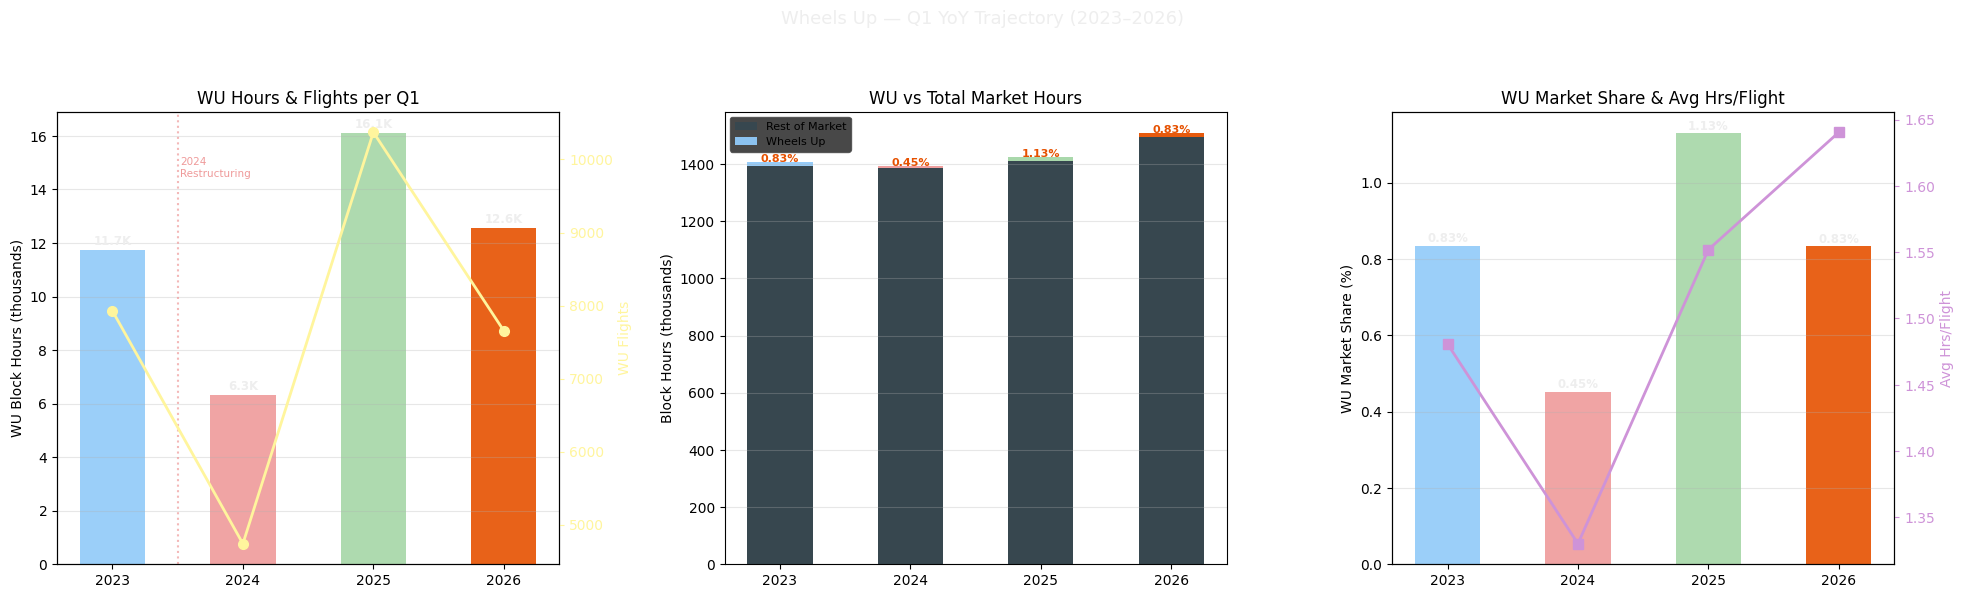

In [5]:
# 2. YoY Trajectory

years = ['2023','2024','2025','2026']
wu_hrs_yoy  = [dfs[y][dfs[y]['is_wu']]['Hours'].sum() for y in years]
wu_flt_yoy  = [len(dfs[y][dfs[y]['is_wu']]) for y in years]
mkt_hrs_yoy = [dfs[y]['Hours'].sum() for y in years]
share_yoy   = [w/m*100 for w, m in zip(wu_hrs_yoy, mkt_hrs_yoy)]
other_hrs   = [m - w for w, m in zip(wu_hrs_yoy, mkt_hrs_yoy)]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle('Wheels Up — Q1 YoY Trajectory (2023–2026)', fontsize=13, color='#eee', y=1.01)

x = np.arange(len(years))

# 1: WU Hours + Flights 
ax = axes[0]
color_bars = [YEAR_COLORS[y] for y in years]
bars = ax.bar(x, [h/1000 for h in wu_hrs_yoy], color=color_bars, alpha=0.9, width=0.5)
ax2 = ax.twinx()
ax2.plot(x, wu_flt_yoy, color='#FFF59D', marker='o', linewidth=2, markersize=7, label='Flights')
ax2.set_ylabel('WU Flights', color='#FFF59D')
ax2.tick_params(axis='y', colors='#FFF59D')
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_ylabel('WU Block Hours (thousands)')
ax.set_title('WU Hours & Flights per Q1')
for i, (h, f) in enumerate(zip(wu_hrs_yoy, wu_flt_yoy)):
    ax.text(i, h/1000 + 0.2, f'{h/1000:.1f}K', ha='center', fontsize=8.5, color='#eee', fontweight='bold')
ax.axvline(0.5, color='#EF9A9A', linewidth=1.5, linestyle=':', alpha=0.7)
ax.text(0.52, max(wu_hrs_yoy)/1000 * 0.9, '2024\nRestructuring', color='#EF9A9A', fontsize=7.5)
ax.grid(axis='y', alpha=0.3)

# 2: Stacked bars — WU vs Market 
ax = axes[1]
ax.bar(x, [o/1000 for o in other_hrs], color='#37474F', width=0.5, label='Rest of Market')
ax.bar(x, [w/1000 for w in wu_hrs_yoy], bottom=[o/1000 for o in other_hrs],
       color=[YEAR_COLORS[y] for y in years], width=0.5, label='Wheels Up', alpha=0.95)
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_ylabel('Block Hours (thousands)')
ax.set_title('WU vs Total Market Hours')
for i, (w, m) in enumerate(zip(wu_hrs_yoy, mkt_hrs_yoy)):
    ax.text(i, m/1000 + 0.5, f'{w/m*100:.2f}%', ha='center', fontsize=8, color='#E65100', fontweight='bold')
ax.legend(edgecolor='#444', fontsize=8)
ax.grid(axis='y', alpha=0.3)

# 3: WU Market Share % + Avg hrs/flight 
ax = axes[2]
ax.bar(x, share_yoy, color=[YEAR_COLORS[y] for y in years], alpha=0.9, width=0.5)
ax.set_xticks(x); ax.set_xticklabels(years)
ax.set_ylabel('WU Market Share (%)')
ax.set_title('WU Market Share & Avg Hrs/Flight')
avg_hpf = [w/f for w, f in zip(wu_hrs_yoy, wu_flt_yoy)]
ax3 = ax.twinx()
ax3.plot(x, avg_hpf, color='#CE93D8', marker='s', linewidth=2, markersize=7, label='Avg Hrs/Flight')
ax3.set_ylabel('Avg Hrs/Flight', color='#CE93D8')
ax3.tick_params(axis='y', colors='#CE93D8')
for i, s in enumerate(share_yoy):
    ax.text(i, s + 0.01, f'{s:.2f}%', ha='center', fontsize=8.5, color='#eee', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout(pad=2)
plt.show()

In [6]:
# 3. WU Fleet & Segment Mix
df26 = dfs['2026']
wu26 = df26[df26['is_wu']].copy()

# Top aircraft models (2026) 
model_tbl = wu26.groupby('aircraft_model').agg(
    tails=('aircraft_tailsign','nunique'),
    flights=('aircraft_tailsign','count'),
    total_hours=('Hours','sum'),
).sort_values('total_hours', ascending=False)
model_tbl['avg_hrs_per_tail'] = (model_tbl['total_hours'] / model_tbl['tails']).round(1)
model_tbl['pct_of_wu'] = (model_tbl['total_hours'] / model_tbl['total_hours'].sum() * 100).round(1)
print("Top 12 aircraft models flown by WU (2026 Q1):")
print(model_tbl.head(12).round(1).to_string())

Top 12 aircraft models flown by WU (2026 Q1):
                    tails  flights  total_hours  avg_hrs_per_tail  pct_of_wu
aircraft_model                                                              
Phenom 300             22     2145       3319.3             150.9       26.4
Citation X             22     1262       2436.8             110.8       19.4
no model available     28     1066       1861.7              66.5       14.8
Hawker 400XP           12     1332       1615.4             134.6       12.9
Challenger 300          9      719       1570.6             174.5       12.5
400-XP                  7      495        615.0              87.9        4.9
G550                    3       98        201.5              67.2        1.6
Phenom 300-E            1       90        158.8             158.8        1.3
GIV-SP                  2       44        119.9              59.9        1.0
Falcon 900EX-EASy       1       44        106.8             106.8        0.9
GVII-G600               1     

In [11]:


# Segment mix YoY 
seg_mix = {}
for yr, df in dfs.items():
    wu = df[df['is_wu']]
    seg_hrs = wu.groupby('aircraft_segment')['Hours'].sum()
    seg_mix[yr] = (seg_hrs / seg_hrs.sum() * 100).round(1)

seg_df = pd.DataFrame(seg_mix).fillna(0)
seg_order = seg_df['2026'].sort_values(ascending=False).index
seg_df = seg_df.loc[seg_order]
print("\nWU Segment Mix YoY (% of WU hours):")
print(seg_df.to_string())


WU Segment Mix YoY (% of WU hours):
                      2023  2024  2025  2026
aircraft_segment                            
Light Jet             46.9  66.7  44.4  55.5
Super Midsize Jet     18.2   0.8  30.8  36.9
Ultra Long Range Jet   0.7   1.1   2.6   3.0
Heavy Jet              3.6   0.0   2.6   2.5
Super Light Jet       28.8  31.1  17.9   1.2
Very Light Jet         0.0   0.4   0.9   0.6
Midsize Jet            1.8   0.0   0.9   0.3
Entry Level Jet        0.1   0.1   0.0   0.0


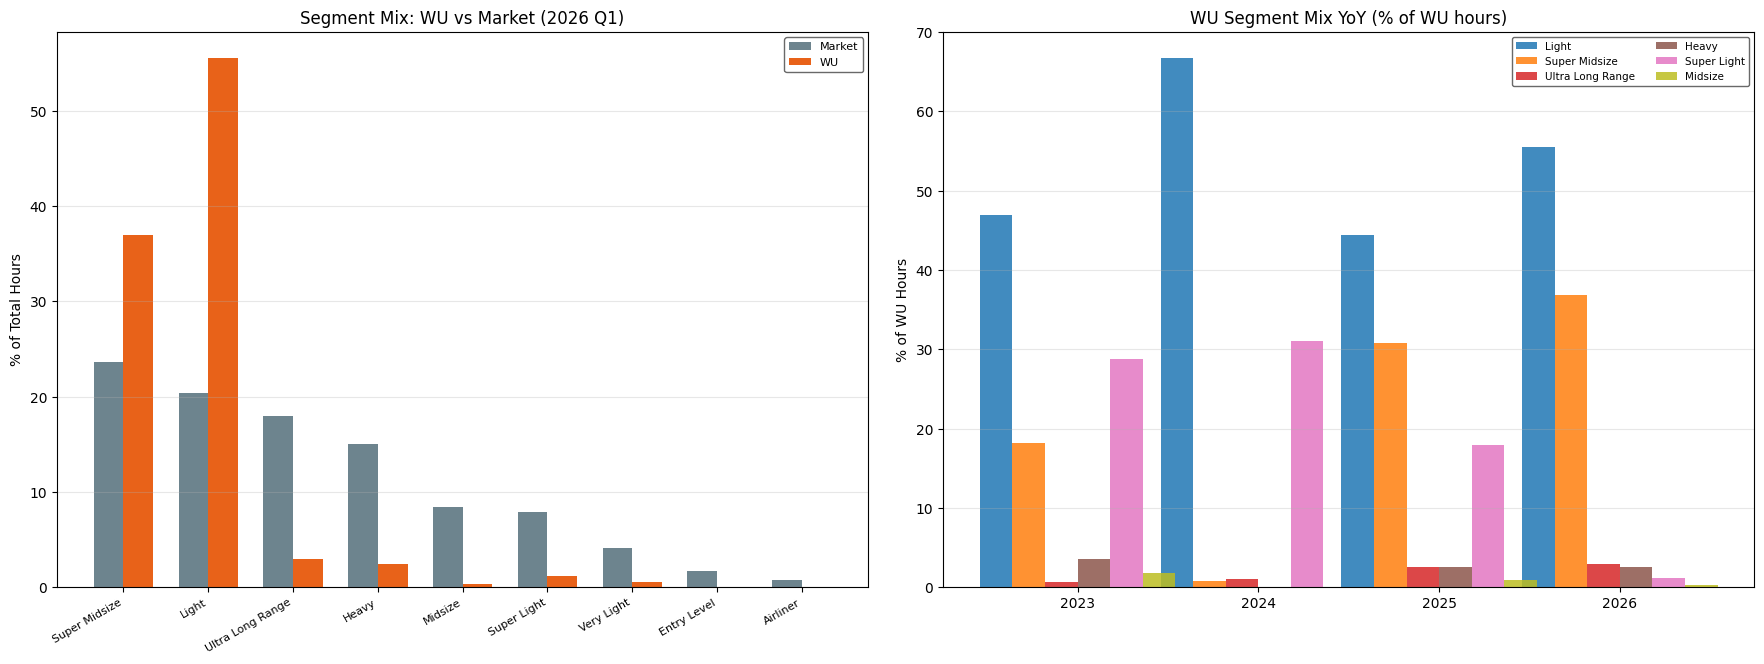

In [12]:
# Chart 
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: WU vs Market segment distribution (2026)
mkt_seg = df26.groupby('aircraft_segment')['Hours'].sum().sort_values(ascending=False)
wu_seg  = wu26.groupby('aircraft_segment')['Hours'].sum().reindex(mkt_seg.index).fillna(0)
wu_seg_pct  = (wu_seg  / wu_seg.sum()  * 100)
mkt_seg_pct = (mkt_seg / mkt_seg.sum() * 100)
segs = mkt_seg.index.tolist()
x = np.arange(len(segs)); w = 0.35
labels_s = [s.replace(' Jet','').replace('Airliner/Bizliner(Jet)','Airliner') for s in segs]
axes[0].bar(x - w/2, mkt_seg_pct.values, w, color='#546E7A', alpha=0.85, label='Market')
axes[0].bar(x + w/2, wu_seg_pct.values,  w, color='#E65100', alpha=0.9,  label='WU')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels_s, rotation=30, ha='right', fontsize=8)
axes[0].set_ylabel('% of Total Hours'); axes[0].set_title('Segment Mix: WU vs Market (2026 Q1)')
axes[0].legend( edgecolor='#444', fontsize=8)
axes[0].grid(axis='y', alpha=0.3)

# Right: WU segment mix YoY (stacked area / grouped bars)
seg_plot = seg_df.loc[seg_df.max(axis=1) > 1]  # segments with >1% in any year
x2 = np.arange(4); bar_w = 0.18
yr_list = ['2023','2024','2025','2026']
offsets = np.linspace(-(len(seg_plot)-1)/2, (len(seg_plot)-1)/2, len(seg_plot)) * bar_w
cmap2 = plt.get_cmap('tab10')
for i, seg in enumerate(seg_plot.index):
    off = (i - len(seg_plot)/2 + 0.5) * bar_w
    vals = [seg_plot.loc[seg, yr] for yr in yr_list]
    axes[1].bar(x2 + off, vals, bar_w, label=seg.replace(' Jet',''), color=cmap2(i/len(seg_plot)), alpha=0.85)
axes[1].set_xticks(x2); axes[1].set_xticklabels(yr_list)
axes[1].set_ylabel('% of WU Hours'); axes[1].set_title('WU Segment Mix YoY (% of WU hours)')
axes[1].legend( edgecolor='#444', fontsize=7.5, ncol=2)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout(pad=2)
plt.show()

In [16]:
# 4. WU Network Coverage
# WU cluster presence 2026
wu_dep_c  = wu26.groupby('from_cluster')['Hours'].sum().rename('wu_dep')
mkt_dep_c = df26.groupby('from_cluster')['Hours'].sum().rename('mkt_dep')
cov = pd.concat([wu_dep_c, mkt_dep_c], axis=1).fillna(0)
cov = cov.drop(index='UNMAPPED', errors='ignore')
cov['wu_share'] = (cov['wu_dep'] / cov['mkt_dep'] * 100).round(2)
cov.index = [x.replace('_CLUSTER','').replace('_',' ') for x in cov.index]
cov = cov.sort_values('wu_dep', ascending=False)

print("WU Cluster Presence (2026 Q1 departures):")
print(cov[cov['wu_dep'] > 0][['wu_dep','mkt_dep','wu_share']].round(1).to_string())
print(f"\nClusters with ZERO WU presence: {list(cov[cov['wu_dep']==0].index)}")

WU Cluster Presence (2026 Q1 departures):
               wu_dep   mkt_dep  wu_share
ATLANTA        1721.4   92633.8       1.9
MIAMI          1581.3  133364.7       1.2
NEW YORK       1179.2   97275.7       1.2
CHICAGO        1146.5   95525.2       1.2
WASHINGTON DC   969.9   63007.6       1.5
ORLANDO         918.9   57049.9       1.6
OTHER           846.8  316929.2       0.3
HOUSTON         558.5   58795.3       1.0
JACKSON HOLE    464.0   36271.0       1.3
DALLAS          442.9   63741.3       0.7
BOSTON          421.3   34299.3       1.2
SAN FRANCISCO   404.7   40991.1       1.0
PHOENIX         310.9   31171.3       1.0
LOS ANGELES     249.4   44027.6       0.6
ASPEN           227.6   19467.3       1.2
VAIL            206.1    9422.1       2.2
SAN DIEGO       184.7   21911.6       0.8
NASSAU          174.7   10902.5       1.6
DENVER          172.3   18469.0       0.9
LAS VEGAS       133.1   22667.8       0.6
SEATTLE          98.2   23247.6       0.4
CABO             26.7   10742.6   

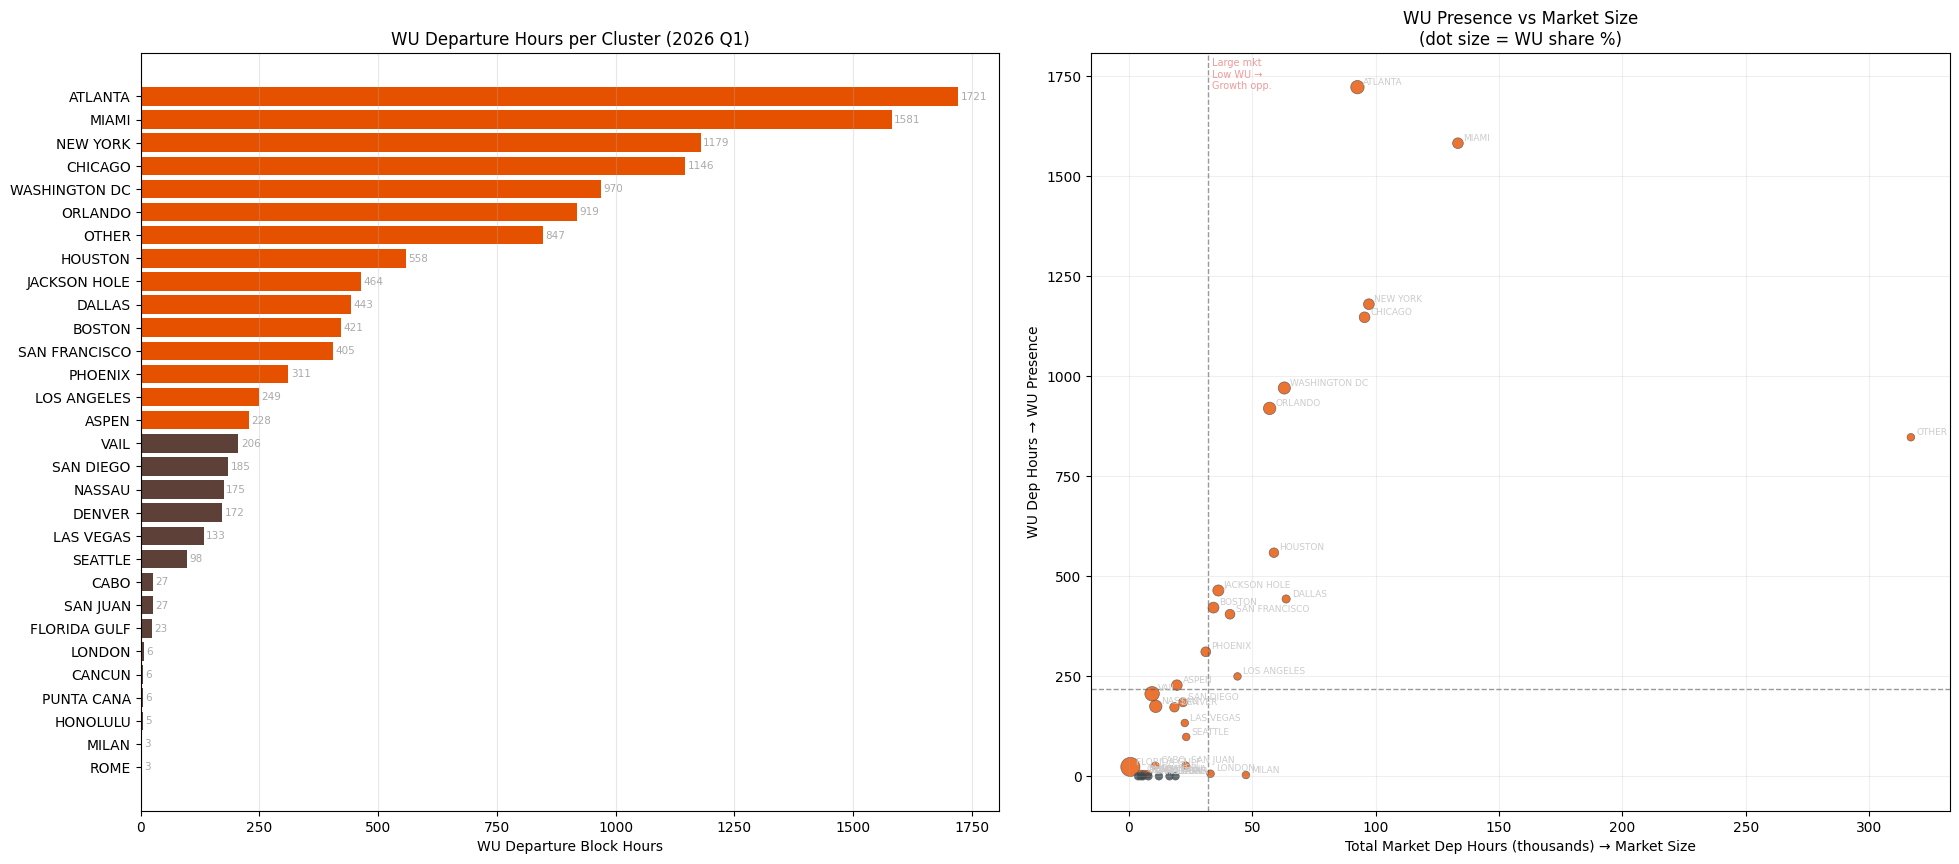

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Left: WU departure hours per cluster (present only)
wu_present = cov[cov['wu_dep'] > 0].sort_values('wu_dep', ascending=True)
bar_colors = ['#E65100' if v > wu_present['wu_dep'].median() else '#5D4037' for v in wu_present['wu_dep']]
axes[0].barh(wu_present.index, wu_present['wu_dep'], color=bar_colors, edgecolor='none')
axes[0].set_xlabel('WU Departure Block Hours')
axes[0].set_title('WU Departure Hours per Cluster (2026 Q1)')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(wu_present['wu_dep']):
    axes[0].text(v + 5, i, f'{v:.0f}', va='center', fontsize=7.5, color='#aaa')

# Right: Scatter — Market size vs WU hours (sized by WU share)
sc_data = cov[(cov['mkt_dep'] > 500)].copy()
sizes = (sc_data['wu_share'] * 50).clip(lower=30)
colors_sc = ['#E65100' if w > 0 else '#37474F' for w in sc_data['wu_dep']]

scatter = axes[1].scatter(sc_data['mkt_dep']/1000, sc_data['wu_dep'],
                          s=sizes, c=colors_sc, alpha=0.8, edgecolors='#555', linewidth=0.5)
axes[1].set_xlabel('Total Market Dep Hours (thousands) → Market Size')
axes[1].set_ylabel('WU Dep Hours → WU Presence')
axes[1].set_title('WU Presence vs Market Size\n(dot size = WU share %)')

# Annotate all clusters
for idx, row in sc_data.iterrows():
    if row['wu_dep'] > 0 or row['mkt_dep'] > 5000:
        axes[1].annotate(idx, (row['mkt_dep']/1000, row['wu_dep']),
                         fontsize=6.5, color='#ccc', ha='left',
                         xytext=(4, 2), textcoords='offset points')

# Quadrant lines at medians (WU-present clusters only)
wu_only = sc_data[sc_data['wu_dep'] > 0]
med_mkt = wu_only['mkt_dep'].median() / 1000
med_wu  = wu_only['wu_dep'].median()
axes[1].axvline(med_mkt, color='#555', linewidth=1, linestyle='--', alpha=0.6)
axes[1].axhline(med_wu,  color='#555', linewidth=1, linestyle='--', alpha=0.6)
axes[1].text(med_mkt * 1.05, axes[1].get_ylim()[1] * 0.95,
             'Large mkt\nLow WU →\nGrowth opp.', fontsize=7, color='#EF9A9A')

axes[1].grid(alpha=0.2)

plt.tight_layout(pad=2)
plt.show()
